## 温泉の泉質データの分析アルゴリズム設計

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import japanize_matplotlib

In [8]:


df = pd.read_excel(
    "/Users/yoshizawakazuki/Downloads/dbghs/東北/宮城.xls",
    engine="xlrd"   # .xls の場合
)

df.head()


,都道府県名,所在地,東経（゜）,東経（′）,東経（″),北緯（゜）,北緯（′）,北緯（″),標高（ｍ）,水源種別,...,ｆｒｅｅ Ｈ２Ｓ,ｆｒｅｅ ＣＯ２,Ｔ−ＣＯ２,Ｔ−Ａｓ,Ｔ−Ｈｇ,Ｔ−Ｐ,Ｔ−Ｂ,単位,調査日,文献名
0,宮城県,NaN,140.0,43.0,20.0,38.0,13.0,20.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,本邦高かん泉の温泉地質学的意義，地調月報，1958
1,宮城県,NaN,140.0,34.0,30.0,38.0,1.0,20.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,本邦高かん泉の温泉地質学的意義，地調月報，1958
2,宮城県,NaN,140.0,34.0,30.0,38.0,1.0,20.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,本邦高かん泉の温泉地質学的意義，地調月報，1958
3,宮城県,NaN,140.0,34.0,30.0,38.0,1.0,20.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,本邦高かん泉の温泉地質学的意義，地調月報，1958
4,宮城県,NaN,140.0,34.0,30.0,38.0,1.0,20.0,NaN,不明,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,本邦高かん泉の温泉地質学的意義，地調月報，1958


In [9]:
df.columns

Index(['都道府県名', '所在地', '東経（゜）', '東経（′）', '東経（″)', '北緯（゜）', '北緯（′）', '北緯（″)',
       '標高（ｍ）', '水源種別', '利用目的', '井戸深度', '採水標高', '気温', '水温', '湧出量', '水質（外観臭味）',
       'ｐＨ', 'ＲｐＨ', 'Ｒｎ(マッヘ)', '比重', '密度', '蒸発残留物', '電気伝導度', '水比抵抗', 'ＥＨ',
       'ＫＭｎＯ４消費', 'Ｈ＋', 'Ｌｉ＋', 'Na＋', 'Ｋ＋', 'Ｒｂ＋', 'Ｃｓ＋', 'ＮＨ４＋', 'Ｍｇ２＋',
       'Ｃａ２＋', 'Ｓｒ２＋', 'Ｂａ２＋', 'Ａｌ３＋', 'Ｍｎ２＋', 'Ｆｅ２＋', 'Ｆｅ３＋', 'Ｔ−Ｆｅ', 'Ｃｕ２＋',
       'Ｚｎ２＋', 'Ｐｂ２＋', 'Ｓｉ４＋', 'Ｆ−', 'Ｃｌ−', 'Ｂｒ−', 'I−', 'OH−', 'ＮＯ２−', 'ＮＯ３−',
       'ＨＳ−', 'Ｓ２Ｏ３2−', 'ＨＳＯ４−', 'ＳＯ４２−', 'ＳＯ３２−', 'Ｈ２ＰＯ４−', 'ＨＰＯ４２−', 'ＰＯ４３−',
       'ＨＣＯ３−', 'ＣＯ３２−', 'ＨＳｉＯ３−', 'ＳｉＯ３２−', 'ＢＯ２−', 'Ｈ２ＳＯ４', 'Ｈ３ＰＯ４', 'ＨＡｓＯ２',
       'ＡｓＯ２-', 'ＳｉO２', 'Ｈ２ＳｉＯ３', 'ＨＢＯ２', 'ｄｉｓ．０２', 'ｆｒｅｅ　Ｈ２Ｓ', 'ｆｒｅｅ　ＣＯ２',
       'Ｔ−ＣＯ２', 'Ｔ−Ａｓ', 'Ｔ−Ｈｇ', 'Ｔ−Ｐ', 'Ｔ−Ｂ', '単位', '調査日', '文献名'],
      dtype='object')

In [36]:
df['ID'] = (
    df['東経（゜）'].astype(str) + '_' +
    df['東経（′）'].astype(str) + '_' +
    df['東経（″)'].astype(str) + '_' +
    df['北緯（゜）'].astype(str) + '_' +
    df['北緯（′）'].astype(str) + '_' +
    df['北緯（″)'].astype(str)
)

In [38]:
df2 = df.dropna(subset=['所在地'])
df.isna().mean().sort_values(ascending=False)

major_cols = [
    'ｐＨ', '水温',
    'Na＋', 'Ｋ＋', 'Ｃａ２＋', 'Ｍｇ２＋',
    'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−'
]

df[major_cols].isna().sum(),len(df)

(ｐＨ        18
 水温        19
 Na＋      102
 Ｋ＋       104
 Ｃａ２＋      58
 Ｍｇ２＋      77
 Ｃｌ−       18
 ＳＯ４２−     24
 ＨＣＯ３−     36
 dtype: int64,
 266)

In [39]:
df.isna().sum()

都道府県名      0
所在地       14
東経（゜）     20
東経（′）     20
東経（″)     20
        ... 
Ｔ−Ｂ      266
単位       169
調査日      204
文献名        0
ID         0
Length: 86, dtype: int64

In [47]:
max_na = 50
df_filtered = df2.loc[:, df2.isna().sum() <= max_na]
df_filtered

,都道府県名,所在地,東経（゜）,東経（′）,東経（″),北緯（゜）,北緯（′）,北緯（″),水源種別,利用目的,水温,ｐＨ,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,文献名,ID
8,宮城県,中新田町,140.0,51.0,10.0,38.0,36.0,20.0,井戸,用水,14,7.3,5.8,9.0,47.3,宮城県大崎平野工業用水源調査報告，地調月報，1962,140.0_51.0_10.0_38.0_36.0_20.0
9,宮城県,中新田町,140.0,50.0,30.0,38.0,35.0,20.0,井戸,用水,19,7.2,7.0,14.7,46.8,宮城県大崎平野工業用水源調査報告，地調月報，1962,140.0_50.0_30.0_38.0_35.0_20.0
10,宮城県,中新田町,140.0,51.0,20.0,38.0,34.0,20.0,井戸,用水,19,7.3,6.9,13.7,50.5,宮城県大崎平野工業用水源調査報告，地調月報，1962,140.0_51.0_20.0_38.0_34.0_20.0
11,宮城県,中新田町,140.0,52.0,30.0,38.0,33.0,0.0,井戸,用水,19,7.4,16.0,13.4,73.6,宮城県大崎平野工業用水源調査報告，地調月報，1962,140.0_52.0_30.0_38.0_33.0_0.0
12,宮城県,古川市,140.0,54.0,0.0,38.0,35.0,0.0,井戸,用水,18.6,7.1,6.1,9.0,48.7,宮城県大崎平野工業用水源調査報告，地調月報，1962,140.0_54.0_0.0_38.0_35.0_0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,宮城県,柴田郡村田町足立六角前,140.0,43.0,7.0,38.0,8.0,23.0,井戸,温泉・鉱泉,20.2,7.2,1416.0,438.8,100.9,秋田地熱資源図説明書，地質調査所，1996,140.0_43.0_7.0_38.0_8.0_23.0
262,宮城県,刈田郡蔵王町,140.0,34.0,42.0,38.0,7.0,21.0,井戸・湧泉,温泉・鉱泉,67,6.8,293.7,898.3,427.0,秋田地熱資源図説明書，地質調査所，1996,140.0_34.0_42.0_38.0_7.0_21.0
263,宮城県,刈田郡蔵王町,140.0,39.0,36.0,38.0,3.0,22.0,井戸,温泉・鉱泉,49,7,5096.0,420.9,117.1,秋田地熱資源図説明書，地質調査所，1996,140.0_39.0_36.0_38.0_3.0_22.0
264,宮城県,白石市福岡蔵本,140.0,34.0,45.0,38.0,1.0,16.0,井戸・湧泉,温泉・鉱泉,40,7.14,755.0,599.0,388.0,秋田地熱資源図説明書，地質調査所，1996,140.0_34.0_45.0_38.0_1.0_16.0


In [48]:
df_filtered.columns

Index(['都道府県名', '所在地', '東経（゜）', '東経（′）', '東経（″)', '北緯（゜）', '北緯（′）', '北緯（″)',
       '水源種別', '利用目的', '水温', 'ｐＨ', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−', '文献名', 'ID'],
      dtype='object')

In [50]:
df_filtered['利用目的'].unique()

df_use = df_filtered[['水源種別', '利用目的', '水温', 'ｐＨ', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−','ID']].dropna()


In [51]:
len(df_use)

211

In [52]:
df_use

,水源種別,利用目的,水温,ｐＨ,Ｃｌ−,ＳＯ４２−,ＨＣＯ３−,ID
8,井戸,用水,14,7.3,5.8,9.0,47.3,140.0_51.0_10.0_38.0_36.0_20.0
9,井戸,用水,19,7.2,7.0,14.7,46.8,140.0_50.0_30.0_38.0_35.0_20.0
10,井戸,用水,19,7.3,6.9,13.7,50.5,140.0_51.0_20.0_38.0_34.0_20.0
11,井戸,用水,19,7.4,16.0,13.4,73.6,140.0_52.0_30.0_38.0_33.0_0.0
12,井戸,用水,18.6,7.1,6.1,9.0,48.7,140.0_54.0_0.0_38.0_35.0_0.0
...,...,...,...,...,...,...,...,...
261,井戸,温泉・鉱泉,20.2,7.2,1416.0,438.8,100.9,140.0_43.0_7.0_38.0_8.0_23.0
262,井戸・湧泉,温泉・鉱泉,67,6.8,293.7,898.3,427.0,140.0_34.0_42.0_38.0_7.0_21.0
263,井戸,温泉・鉱泉,49,7,5096.0,420.9,117.1,140.0_39.0_36.0_38.0_3.0_22.0
264,井戸・湧泉,温泉・鉱泉,40,7.14,755.0,599.0,388.0,140.0_34.0_45.0_38.0_1.0_16.0


/Users/yoshizawakazuki/.pyenv/versions/3.12.8/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


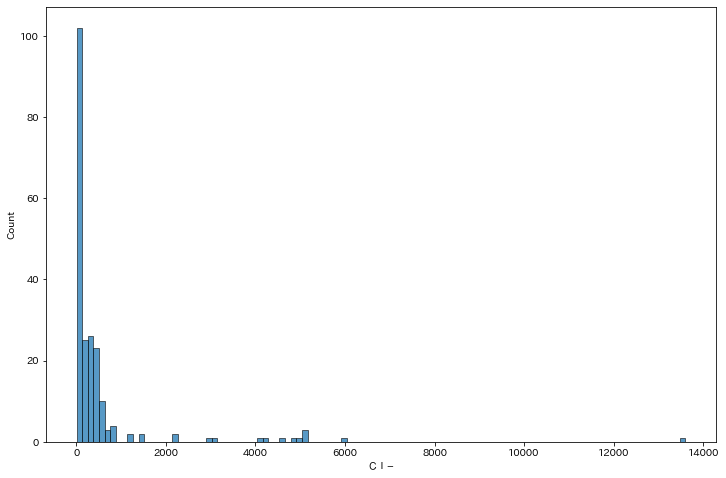

In [59]:
plt.figure(figsize=(12,8))
sns.histplot(x='Ｃｌ−',data=df_use)
plt.show()

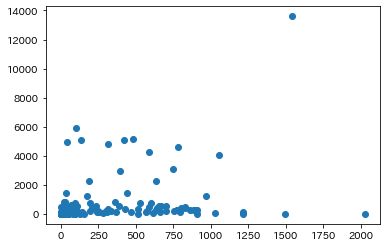

In [62]:
plt.scatter(x='ＳＯ４２−',y='Ｃｌ−',data=df_use)

In [63]:
# PCA: 

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
def pca(df,subset):
    scaler = StandardScaler()
    X_pca = scaler.fit_transform(subset)

    # PCA
    pca = PCA()
    pca.fit(X_pca)

    pcs = pca.transform(X_pca)

    """
    Return DataFrame
    """
    pcs_df = pd.DataFrame(pcs, index=df.index,
                      columns=[f"PC{i+1}" for i in range(pcs.shape[1])])

    explained = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_,
                        columns=subset.columns,
                        index=[f"PC{i+1}" for i in range(len(pca.components_))])
    

    # 累積寄与率を計算
    cumsum = np.cumsum(pca.explained_variance_ratio_)

    # 閾値（例: 90%）を超える最小の成分数を探す
    threshold = 0.90
    d_cumsum = np.argmax(cumsum >= threshold) + 1

    print(f"累積寄与率 {threshold*100}% 基準: {d_cumsum} Components")

    pca_mle = PCA(n_components='mle')
    pca_mle.fit(X_pca)
    d_mle = pca_mle.n_components_
    print(f"MLE法: {d_mle} Components")


    fig,ax = plt.subplots(2,2,figsize=(14,7))
    
    ax[0,0].bar(range(1, 6), pca.explained_variance_ratio_[:5])
    ax[0,0].set_xticks(range(1,9))
    ax[0,0].set_ylabel("Explained variance ratio")
    ax[0,0].set_title("PC1–PC10 Variance Explained")


    
    ax[0,1].plot(range(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_, marker="o")
    ax[0,1].set_title("Scree Plot (Variance Explained)")
    ax[0,1].set_xlabel("Principal Component")
    ax[0,1].set_ylabel("Variance Ratio")
    ax[0,1].grid(True)
    
    loadings = pd.DataFrame(
    pca.components_,
    columns=subset.columns,
    index=[f"PC{i+1}" for i in range(len(pca.components_))]
)

    
    n_loadings = min(5, len(loadings))
    im = ax[1, 0].imshow(loadings.iloc[:n_loadings], cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
    ax[1, 0].set_title(f"PCA Loadings (Top {n_loadings} PCs)")
    ax[1, 0].set_yticks(range(n_loadings))
    ax[1, 0].set_yticklabels(loadings.index[:n_loadings])
    ax[1, 0].set_xticks(range(len(loadings.columns)))
    ax[1, 0].set_xticklabels(loadings.columns, rotation=90)
    fig.colorbar(im, ax=ax[1, 0], orientation='vertical')



    plt.tight_layout()
    plt.show()


    # (A) 各主成分のZ-score化 (Standardized PC Scores)
    # 主成分スコアを標準偏差(固有値の平方根)で割る
    pc_std_dev = np.sqrt(pca.explained_variance_)
    z_scores_pc = pcs / pc_std_dev

    #z_scores_pc

    t2_scores = np.sum(z_scores_pc ** 2, axis=1) #t2_scores 

    X_recon = pca.inverse_transform(pcs) # 復元
    diff = X_pca - X_recon
    q_statistics = np.sum(diff ** 2, axis=1)


    df_result = subset.copy()
    df_result['PC1'] = pcs[:, 0]
    df_result['PC2'] = pcs[:, 1]
    df_result['PC3'] = pcs[:, 2]
    df_result['PC4'] = pcs[:, 3]
    df_result['PC5'] = pcs[:, 4]


    df_result['PC1_Z'] = z_scores_pc[:, 0] # PC1のZscore
    df_result['PC2_Z'] = z_scores_pc[:, 1] # PC2のZscore
    df_result['PC3_Z'] = z_scores_pc[:, 2]  
    df_result['PC4_Z'] = z_scores_pc[:, 3] 
    df_result['PC5_Z'] = z_scores_pc[:, 4] 


    df_result['T2'] = t2_scores            # 異常度1 (中心からの距離)
    df_result['Q_Stat'] = q_statistics     # 異常度2 (モデルからの乖離)

    print("--- 結果の上位5行 ---")
    print(df_result.head())

    print("\n--- 外れ値箇所のスコア確認 ---")
    print(df_result.tail(2))

    # 各変数がどの程度主成分に寄与しているかどうかをみる
    df_components = pd.DataFrame(
        pca.components_,
        columns=subset.columns,  # 元の変数名リスト
        index=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    # print("--- 各主成分への変数の寄与（固有ベクトル） ---")
    # print(df_components)

    return df_result,df_components

In [74]:
df_use.columns

Index(['水源種別', '利用目的', '水温', 'ｐＨ', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−', 'ID'], dtype='object')

累積寄与率 90.0% 基準: 5 Components
MLE法: 3 Components


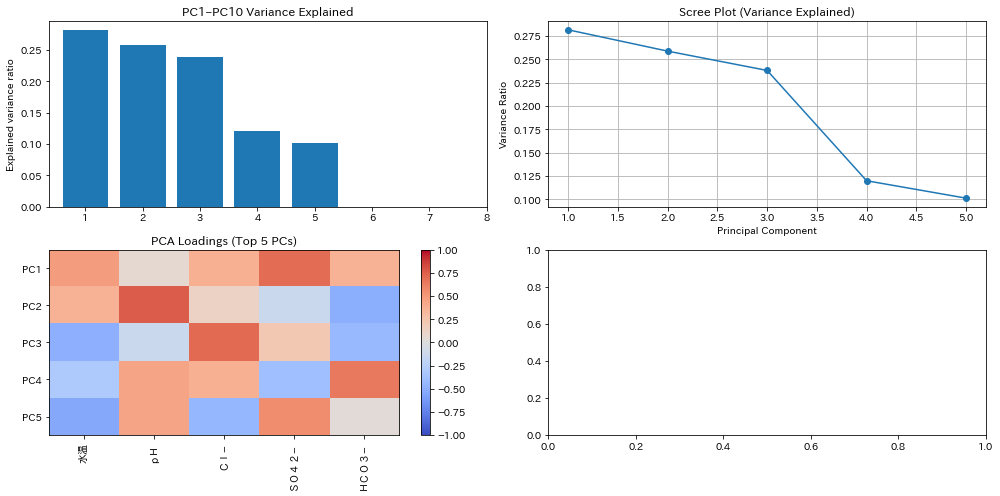

--- 結果の上位5行 ---
      水温   ｐＨ   Ｃｌ−  ＳＯ４２−  ＨＣＯ３−       PC1       PC2       PC3       PC4  \
8     14  7.3   5.8    9.0   47.3 -1.438539 -0.234790  0.525713 -0.051634   
9     19  7.2   7.0   14.7   46.8 -1.355535 -0.269183  0.463641 -0.164479   
10    19  7.3   6.9   13.7   50.5 -1.343321 -0.182639  0.440046 -0.098793   
11    19  7.4  16.0   13.4   73.6 -1.297193 -0.136215  0.386309  0.020856   
12  18.6  7.1   6.1    9.0   48.7 -1.379332 -0.369932  0.479063 -0.203861   

         PC5     PC1_Z     PC2_Z     PC3_Z     PC4_Z     PC5_Z        T2  \
8   0.359170 -1.209406 -0.205915  0.480638 -0.066489  0.503214  1.993723   
9   0.222909 -1.139624 -0.236078  0.423889 -0.211799  0.312306  1.676550   
10  0.276633 -1.129355 -0.160177  0.402316 -0.127215  0.387576  1.629356   
11  0.331128 -1.090575 -0.119463  0.353186  0.026856  0.463927  1.544314   
12  0.166696 -1.159630 -0.324437  0.437988 -0.262511  0.233550  1.765292   

          Q_Stat  
8   8.566536e-31  
9   7.426386e-31  
10  3.7

In [75]:
subset = df_use[['水温', 'ｐＨ', 'Ｃｌ−', 'ＳＯ４２−', 'ＨＣＯ３−']]
df_result, df_components= pca(df_use,subset)

In [76]:
# Parallel Analysis: 
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import PCA

def parallel_analysis(X, n_iter=1000, percentile=95):
    n, p = X.shape
    pca = PCA()
    pca.fit(X)
    ev_real = pca.explained_variance_

    ev_rand = np.zeros((n_iter, p))

    for i in tqdm(range(n_iter), desc="Parallel Analysis"):
        X_rand = np.random.normal(size=(n, p))
        pca.fit(X_rand)
        ev_rand[i] = pca.explained_variance_

    ev_rand_percentile = np.percentile(ev_rand, percentile, axis=0)
    return ev_real, ev_rand_percentile


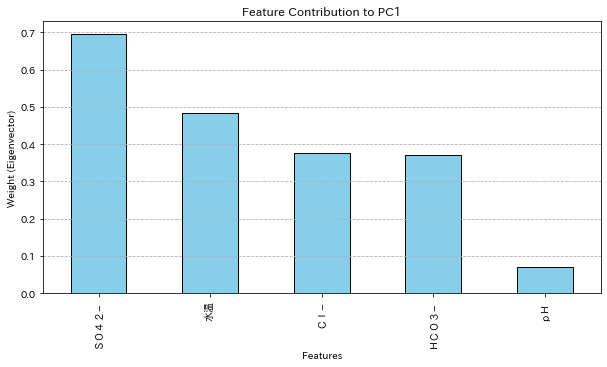

In [78]:
"""
PCごとのデータを取り出す
"""

# PC1のデータを取り出す
pc1_weights = df_components.loc['PC1']
# 寄与度の絶対値でソートして棒グラフにする（影響力が強い順）
# abs()をつけるかどうかは目的によりますが、ここでは「影響の強さ」を見るため絶対値でソート
pc1_weights_sorted = pc1_weights.abs().sort_values(ascending=False)
# ※ グラフ描画時は元の符号(正負)を残して表示するのが一般的です
pc1_weights_plot = pc1_weights[pc1_weights_sorted.index]

plt.figure(figsize=(10, 5))
pc1_weights_plot.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Feature Contribution to PC1')
plt.xlabel('Features')
plt.ylabel('Weight (Eigenvector)')
plt.axhline(0, color='grey', linewidth=0.8) # 0のライン
plt.grid(axis='y', linestyle='--')
plt.show()

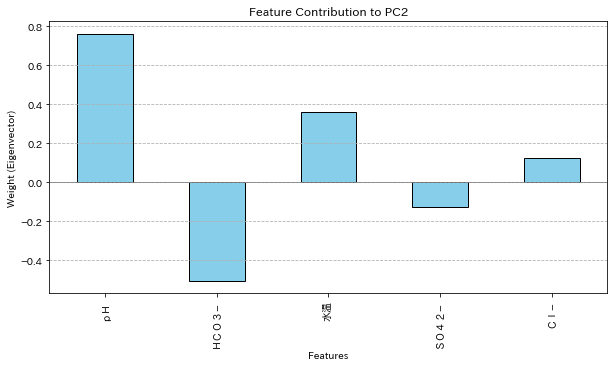

In [79]:
"""
PCごとのデータを取り出す
"""

# PC1のデータを取り出す
pc1_weights = df_components.loc['PC2']
# 寄与度の絶対値でソートして棒グラフにする（影響力が強い順）
# abs()をつけるかどうかは目的によりますが、ここでは「影響の強さ」を見るため絶対値でソート
pc1_weights_sorted = pc1_weights.abs().sort_values(ascending=False)
# ※ グラフ描画時は元の符号(正負)を残して表示するのが一般的です
pc1_weights_plot = pc1_weights[pc1_weights_sorted.index]

plt.figure(figsize=(10, 5))
pc1_weights_plot.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Feature Contribution to PC2')
plt.xlabel('Features')
plt.ylabel('Weight (Eigenvector)')
plt.axhline(0, color='grey', linewidth=0.8) # 0のライン
plt.grid(axis='y', linestyle='--')
plt.show()

In [80]:
# Rador Chart 
def plot_multi_pc_radar(loadings, pcs):
    labels = loadings.columns.tolist()
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    for pc in pcs:
        values = loadings.loc[pc].values
        values = np.concatenate([values, [values[0]]])
        ax.plot(angles, values, label=pc, linewidth=2)
        ax.fill(angles, values, alpha=0.15)

    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_ylim(-1, 1)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    ax.set_title("PCA Loadings Radar Chart")

    plt.show()


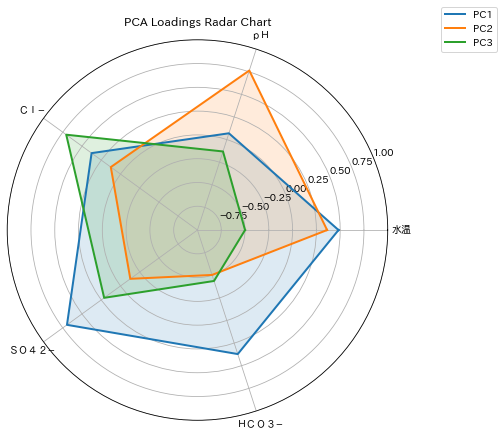

In [81]:
plot_multi_pc_radar(df_components, ["PC1", "PC2","PC3"])


In [ ]:
# それぞれの温泉地がどの範囲に分布しているか見たい：　クラスター作り
# PC成分ごとの分布を見るなど